In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv("/content/product_return_prediction.csv")
df.head(20)

,order_id,product_id,price,rating,return_status
0,O0001,P909,141.90,3,0
1,O0002,P778,232.72,3,0
2,O0003,P508,496.90,3,0
3,O0004,P763,138.81,3,0
4,O0005,P255,453.40,1,1
5,O0006,P881,48.02,5,0
6,O0007,P144,430.74,2,1
7,O0008,P678,253.85,5,0
8,O0009,P670,329.87,5,0
9,O0010,P612,119.48,2,0


In [7]:
df.columns

Index(['order_id', 'product_id', 'price', 'rating', 'return_status'], dtype='object')

1500 Rows and 5 Columns are there

In [14]:
print(df.shape)
df.info()
df.describe()

(1500, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   object 
 1   product_id     1500 non-null   object 
 2   price          1500 non-null   float64
 3   rating         1500 non-null   int64  
 4   return_status  1500 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 58.7+ KB


,price,rating,return_status
count,1500.000000,1500.000000,1500.000000
mean,251.344100,2.985333,0.270667
std,139.258771,1.404196,0.444452
min,10.430000,1.000000,0.000000
25%,131.625000,2.000000,0.000000
50%,250.135000,3.000000,0.000000
75%,367.025000,4.000000,1.000000
max,499.690000,5.000000,1.000000


In [21]:
print(df.isnull().sum())
df.duplicated().sum()

order_id         0
product_id       0
price            0
rating           0
return_status    0
dtype: int64


np.int64(0)

Return Distribution

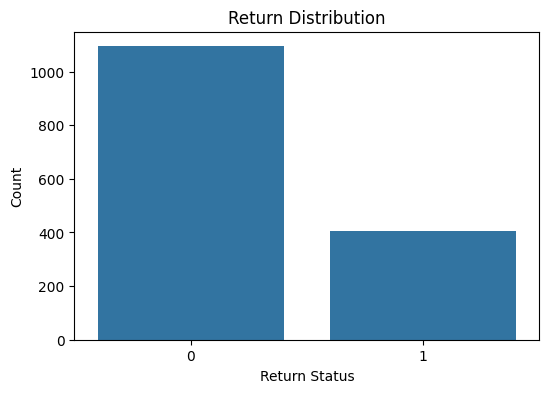

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='return_status',
    data=df
)

plt.title('Return Distribution')
plt.xlabel('Return Status')
plt.ylabel('Count')

plt.show()

### Rating Distribution

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Return Status by Rating

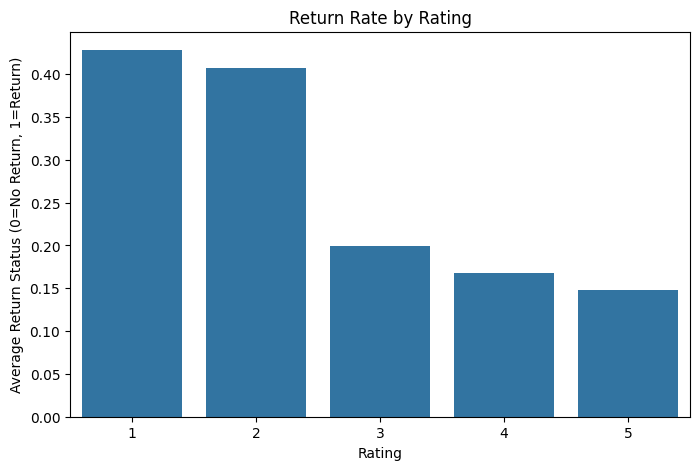

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x='rating', y='return_status', data=df, errorbar=None)
plt.title('Return Rate by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Return Status (0=No Return, 1=Return)')
plt.show()

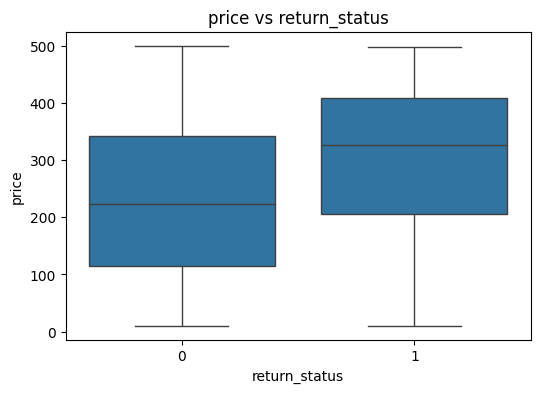

In [29]:
plt.figure(figsize=(6,4))

sns.boxplot(x="return_status",y="price", data=df)
plt.title("price vs return_status")
plt.xlabel("return_status")
plt.ylabel("price")

plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

df_heatmap = df.copy()

le = LabelEncoder()

df_heatmap['return_status'] = le.fit_transform(
    df_heatmap['return_status']
)


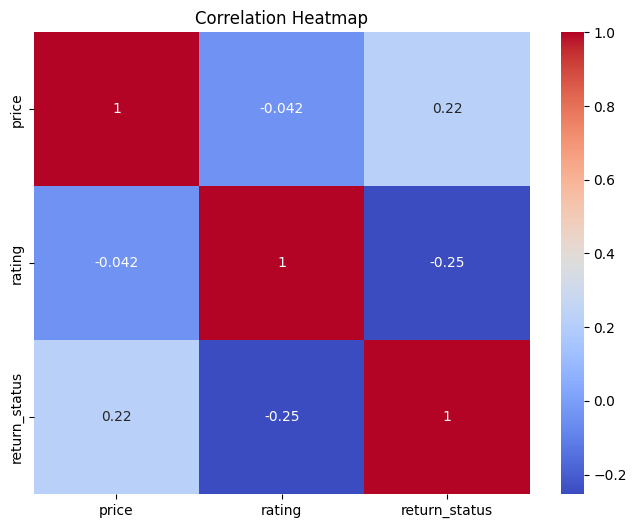

In [33]:
plt.figure(figsize=(8,6))

# Select only numeric columns for correlation calculation
numeric_df_heatmap = df_heatmap.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df_heatmap.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Feature Engineering**

In [44]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported for pd.read_csv

# Reload the original dataframe to ensure 'product_id' and 'order_id' are present
df = pd.read_csv("/content/product_return_prediction.csv")

le = LabelEncoder() # This 'le' is for 'return_status' as per original code

le_product = LabelEncoder() # This 'le_product' is for 'product_id'
df['product_id'] = le_product.fit_transform(df['product_id'])

# Define features (X) and target (y)
X = df[['product_id', 'price', 'rating']]
y = df['return_status']

# Encode 'return_status' (which is already 0/1 int64, so this step is mostly for consistency)
df['return_status'] = le.fit_transform(df['return_status'])

print(f"Return status mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Drop 'order_id' and the original 'product_id' from the main df
# (product_id in df is now encoded, order_id is an identifier and not used in X)
df.drop(['order_id', 'product_id'], axis=1, inplace=True)

print("\nDataFrame head after transformations:")
print(df.head())

Return status mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

DataFrame head after transformations:
    price  rating  return_status
0  141.90       3              0
1  232.72       3              0
2  496.90       3              0
3  138.81       3              0
4  453.40       1              1


In [50]:
from sklearn.model_selection import train_test_split

X = df.drop('return_status', axis=1)
y = df['return_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 2)
(300, 2)


In [54]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [55]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.67


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78       210
           1       0.42      0.28      0.34        90

    accuracy                           0.67       300
   macro avg       0.58      0.56      0.56       300
weighted avg       0.64      0.67      0.65       300



**Comparision**

In [57]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6566666666666666


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators':[200,300,500],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
Accuracy: 0.6566666666666666


**Confusion Matrix**

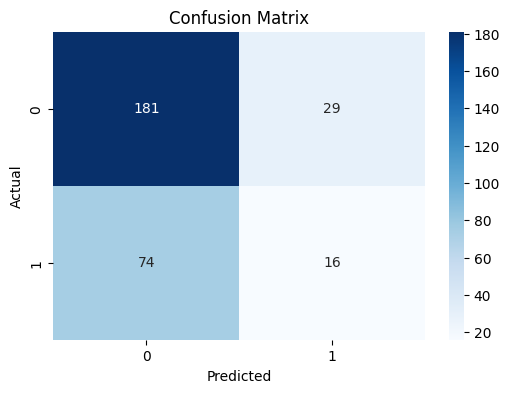

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Feature Importance**

In [63]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':model.feature_importances_

})

In [64]:
importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,rating,0.594861
0,price,0.405139


**Risk Score**

In [65]:
risk_scores = model.predict_proba(
    X_test
)[:,1]

In [66]:
results = X_test.copy()

results['Risk Score'] = risk_scores

results.head()

,price,rating,Risk Score
1116,405.67,3,0.276549
1368,167.52,2,0.559008
422,380.15,2,0.462536
413,237.46,4,0.056784
451,254.13,2,0.150211


**Save Model**

In [67]:
import joblib

joblib.dump(
    model,
    'return_prediction_model.pkl'
)

['return_prediction_model.pkl']

**Download Model**

In [68]:
from google.colab import files

files.download(
    'return_prediction_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>